In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
from collections import Counter
import nltk
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score

from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Need to run once for stemming later
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [2]:
# Load the data from the .txt file into a data frame for easier use later
texts = []
labels = []

# Use the original file path to read the file line by line
with open('/content/drive/MyDrive/sentiment labelled sentences/amazon_cells_labelled.txt', "r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()
        if not line:
            continue
        # Split by tab instead of space to handle lines with tabs
        parts = line.split('\t')
        if len(parts) == 2:
            text, label = parts
            texts.append(text)
            labels.append(int(label))
        else:
            # Handle cases where the line doesn't have exactly two parts after splitting by tab
            print(f"Skipping line due to unexpected format: {line}")


df = pd.DataFrame({"text": texts, "sentiment": labels})
print(df.head())

                                                text  sentiment
0  So there is no way for me to plug it in here i...          0
1                        Good case, Excellent value.          1
2                             Great for the jawbone.          1
3  Tied to charger for conversations lasting more...          0
4                                  The mic is great.          1


In [11]:
# Calculate word count for each review
word_counts = [len(str(review).split()) for review in df['text']]

# Find the maximum word count
max_word_count = max(word_counts)

# Find the index of the longest review
longest_review_index = word_counts.index(max_word_count)

# Get the longest review
longest_review = df['text'].iloc[longest_review_index]

print("LONGEST REVIEW IN DATASET")
print(f"Length: {max_word_count} words")
print(f"Index: {longest_review_index}")
print(f"Sentiment: {df['sentiment'].iloc[longest_review_index]}")
print(f"\nReview text:")
print(longest_review)


LONGEST REVIEW IN DATASET
Length: 30 words
Index: 65
Sentiment: 0

Review text:
The one big drawback of the MP3 player is that the buttons on the phone's front cover that let you pause and skip songs lock out after a few seconds.


In [3]:
# Check for presence of unusual characters (e.g. emojis, non-English characters)
# Emoji pattern
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # flags
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    u"\U00002500-\U00002BEF"  # additional symbols
    u"\U00010000-\U0010ffff"  # supplementary characters
    "]+", flags=re.UNICODE)

# Check for emojis
df['has_emoji'] = df['text'].apply(lambda x: bool(emoji_pattern.search(str(x))))

# Check for non-English characters (characters outside standard ASCII)
df['has_non_english'] = df['text'].apply(lambda x: any(ord(char) > 127 for char in str(x)))

print(f"Reviews with emojis: {df['has_emoji'].sum()}")
print(f"Reviews with non-English chars: {df['has_non_english'].sum()}")

# Show examples if they exist
if df['has_emoji'].any():
    print("\nExample reviews with emojis:")
    print(df[df['has_emoji']]['text'].head())

if df['has_non_english'].any():
    print("\nExample reviews with non-English characters:")
    print(df[df['has_non_english']]['text'].head(3))

# Get rid of the new columns after for cleanliness
df = df.drop(['has_emoji', 'has_non_english'], axis=1)

Reviews with emojis: 0
Reviews with non-English chars: 0


In [4]:
# Create cleaned version of the data frame
df_cleaned = df.copy()
# Clean the reviews
df_cleaned['text'] = df_cleaned['text'].apply(lambda x: str(x))

# Step 1: Remove emojis
df_cleaned['text'] = df_cleaned['text'].apply(lambda x: emoji_pattern.sub(r'', x))

# Step 2: Remove non-English characters (keep only ASCII characters, spaces, and basic punctuation temporarily)
df_cleaned['text'] = df_cleaned['text'].apply(lambda x: ''.join(char for char in x if ord(char) < 128))

# Step 3: Remove all punctuation (keep only letters, numbers, and spaces)
df_cleaned['text'] = df_cleaned['text'].apply(lambda x: re.sub(r'[^\w\s]', ' ', x))

# Step 4: Remove extra whitespace (multiple spaces to single space)
df_cleaned['text'] = df_cleaned['text'].apply(lambda x: ' '.join(x.split()))

# Step 5: Strip leading/trailing whitespace
df_cleaned['text'] = df_cleaned['text'].str.strip()

# Step 6: Convert to lowercase for consistency
df_cleaned['text'] = df_cleaned['text'].str.lower()

print(df_cleaned.head())

                                                text  sentiment
0  so there is no way for me to plug it in here i...          0
1                          good case excellent value          1
2                              great for the jawbone          1
3  tied to charger for conversations lasting more...          0
4                                   the mic is great          1


In [5]:
# Apply stemming to finish the cleaning of the data set/frame
stemmer = PorterStemmer()
df_cleaned['text'] = df_cleaned['text'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))

print(df_cleaned.head())

                                                text  sentiment
0  so there is no way for me to plug it in here i...          0
1                               good case excel valu          1
2                               great for the jawbon          1
3  tie to charger for convers last more than 45 m...          0
4                                   the mic is great          1


In [6]:
# Check word count statistics
word_count = [len(str(review).split()) for review in df_cleaned['text']]

print(f"\nWord count statistics:")
print(f"  Average words per review: {np.mean(word_count):.2f}")
print(f"  Median words per review: {np.median(word_count):.2f}")
print(f"  Min words: {min(word_count)}")
print(f"  Max words: {max(word_count)}")

# Character count per review (stored as a list)
char_count = [len(str(review)) for review in df_cleaned['text']]

print(f"\nCharacter count statistics:")
print(f"  Average characters per review: {np.mean(char_count):.2f}")
print(f"  Median characters per review: {np.median(char_count):.2f}")
print(f"  Min characters: {min(char_count)}")
print(f"  Max characters: {max(char_count)}")


Word count statistics:
  Average words per review: 10.47
  Median words per review: 9.00
  Min words: 1
  Max words: 31

Character count statistics:
  Average characters per review: 49.55
  Median characters per review: 43.00
  Min characters: 5
  Max characters: 144


In [7]:
# Get the counts (distributions) of the scores
df_cleaned['sentiment'].value_counts()

,count
sentiment,
0,500
1,500


In [8]:
# Split the data set into a training, testing, and validation set
# We will use a 70%/15%/15% split per industry standards
train_df, temp_df = train_test_split(df_cleaned, test_size=0.3, random_state=42, stratify=df_cleaned['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['sentiment'])

In [9]:
# Export the data set to a .csv file
df_cleaned.to_csv('/content/drive/MyDrive/sentiment labelled sentences/amazon_cells_labelled_cleaned.csv', index=False) # Full dataset
train_df.to_csv('/content/drive/MyDrive/sentiment labelled sentences/amazon_cells_labelled_train.csv', index=False) # Training set
val_df.to_csv('/content/drive/MyDrive/sentiment labelled sentences/amazon_cells_labelled_val.csv', index=False) # Validation set
test_df.to_csv('/content/drive/MyDrive/sentiment labelled sentences/amazon_cells_labelled_test.csv', index=False) # Testing set

In [16]:
# Get vocabulary size
review = df_cleaned.text.values
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(review)
vocab_size = len(tokenizer.word_index) + 1

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 1535


In [12]:
# Set embed_size (we will default to 128 because of convention)
embed_size = 128
# Set maximum sequence length
max_len = 30

In [13]:
# Apply the tokenizer and pad to a max length
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_df['text'])

# First, convert the text to sequences
X_train = tokenizer.texts_to_sequences(train_df['text'])
X_val = tokenizer.texts_to_sequences(val_df['text'])
X_test = tokenizer.texts_to_sequences(test_df['text'])

# Pad sequences to same length
X_train = pad_sequences(X_train, maxlen=max_len, padding='post', truncating='post')
X_val = pad_sequences(X_val, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

# Get labels
y_train = train_df['sentiment'].values
y_val = val_df['sentiment'].values
y_test = test_df['sentiment'].values

In [14]:
# Sample encoding and padding on a review
print(X_train[0])

[  7  36  15   4  18  45 138   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [17]:
# Create the LSTM Network that will be used for sentiment analysis on the data set
model = Sequential()
model.add(Embedding(vocab_size, embed_size, input_shape= (X_train.shape[1],)))
model.add(LSTM(units=50, activation='tanh'))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 128)        │       196,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        35,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,331 (907.54 KB)

 Trainable params: 232,331 (907.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
# Implement stopping criteria via defining early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=3, # Stop if no improvement for 3 epochs
    restore_best_weights=True, # Restore weights from best epoch
    verbose=1 # Print when stopping
)

In [19]:
# Fit the model
history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.4788 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4885 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5244 - loss: 0.6917 - val_accuracy: 0.4933 - val_loss: 0.6931
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4843 - loss: 0.6949 - val_accuracy: 0.4933 - val_loss: 0.6930
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4891 - loss: 0.6941 - val_accuracy: 0.5067 - val_loss: 0.6929
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5531 - loss: 0.6897 - val_accuracy: 0.4933 - val_loss: 0.6928
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5196 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5690 - loss: 0.6844 - val_accuracy: 0.6733 - val_loss: 0.6824


In [ ]:
# Save model
model.save('lstm_model.keras')

In [20]:
# Compare accuracy/loss of the training data set to the validation set
history.history

{'accuracy': [0.48428571224212646,
  0.49142858386039734,
  0.5342857241630554,
  0.4985714256763458,
  0.47999998927116394,
  0.545714259147644,
  0.5371428728103638,
  0.5942857265472412,
  0.7542856931686401,
  0.8714285492897034,
  0.9142857193946838,
  0.954285740852356,
  0.9642857313156128,
  0.9842857122421265,
  0.9857142567634583],
 'loss': [0.6943048238754272,
  0.6939206123352051,
  0.6915213465690613,
  0.6941196322441101,
  0.6950012445449829,
  0.6901162266731262,
  0.6916272044181824,
  0.6828683018684387,
  0.6286787390708923,
  0.4308827519416809,
  0.3017679750919342,
  0.1820184290409088,
  0.15221922099590302,
  0.08378356695175171,
  0.07548706233501434],
 'val_accuracy': [0.5,
  0.5,
  0.4933333396911621,
  0.4933333396911621,
  0.5066666603088379,
  0.4933333396911621,
  0.5,
  0.6733333468437195,
  0.7866666913032532,
  0.7933333516120911,
  0.800000011920929,
  0.8199999928474426,
  0.8066666722297668,
  0.7933333516120911,
  0.8066666722297668],
 'val_loss': 

In [21]:
# Plot training and validation accuracy scores
def plot_learningCurve(history, epochs):
  epoch_range=range(1,epochs+1)
  plt.plot(epoch_range,history.history['accuracy'])
  plt.plot(epoch_range,history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train','Val'],loc='upper left')
  plt.show()

  plt.plot(epoch_range,history.history['loss'])
  plt.plot(epoch_range,history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train','Val'],loc='upper left')
  plt.show()

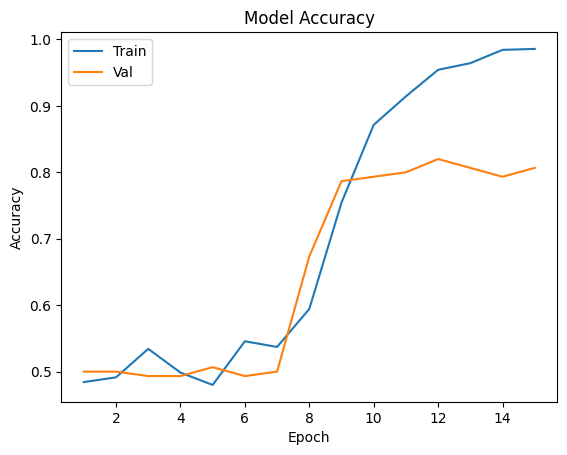

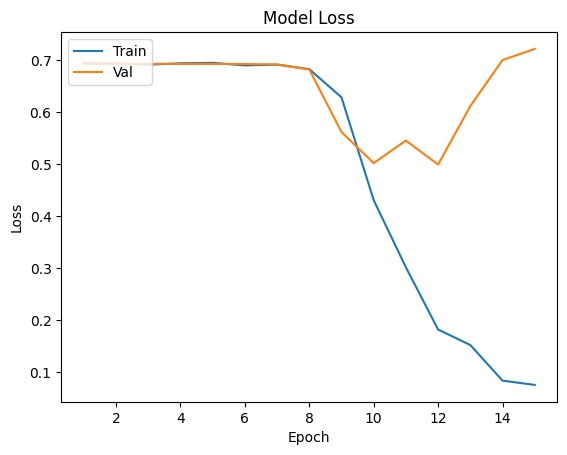

In [23]:
plot_learningCurve(history, 15)

In [24]:
# Evaluate the model against the test dataset
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7513 - loss: 0.7032 


[0.6283255815505981, 0.7799999713897705]

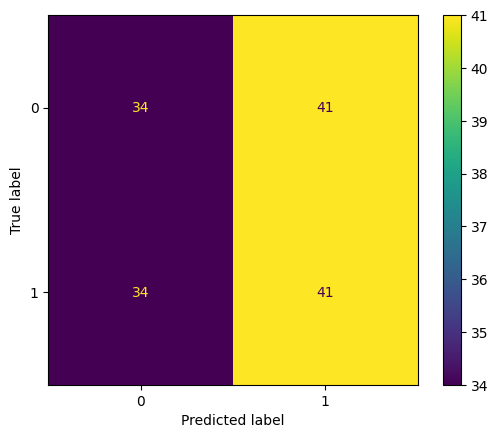

In [25]:
# Confusion Matrix
clf = SVC(random_state=0)
clf.fit(X_train, y_train)
SVC(random_state=0)
predictions=clf.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()